In [213]:
%pip install great_expectations -U

In [214]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json 

# Load data
df = pd.read_csv(r"C:\Users\CS\Downloads\archive\olist_master_dataset.csv")

print("Data Loaded")
print(df.shape)
df.head()

Data Loaded
(119143, 43)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_lat,customer_lng,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,-23.576983,-46.587161,-23.680729,-46.444238
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,-23.576983,-46.587161,-23.680729,-46.444238
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,-23.576983,-46.587161,-23.680729,-46.444238
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,-12.177924,-44.660711,-19.807681,-43.980427
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,-16.745150,-48.514783,-21.363502,-48.229601


In [215]:
print("Dataset Info:")
df.info()

print("\n Missing Values:")
df.isnull().sum().sort_values(ascending=False).head(10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id   

review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_category                   2567
product_photos_qty                 2542
product_name_lenght                2542
product_description_lenght         2542
order_delivered_carrier_date       2086
seller_lat                         1098
seller_lng                         1098
dtype: int64

In [216]:
df = df.drop_duplicates()

print("After removing duplicates:")
print(df.shape)

After removing duplicates:
(119143, 43)


In [217]:
df['payment_value'] = df['payment_value'].fillna(0)
df['freight_value'] = df['freight_value'].fillna(0)
df['review_score'] = df['review_score'].fillna(
    round(df['review_score'].median())
).clip(1, 5)

print("Missing values handled")

Missing values handled


In [218]:
# remove null product_id
df = df[df['product_id'].notnull()]

# remove canceled orders
df = df[df['order_status'] != 'canceled']

print("After removing invalid rows:")
print(df.shape)

After removing invalid rows:
(117740, 43)


In [219]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

df['payment_value'] = df['payment_value'].astype(float)

print("Data types converted")
df.dtypes.head()

Data types converted


order_id                            object
customer_id                         object
order_status                        object
order_purchase_timestamp    datetime64[ns]
order_approved_at                   object
dtype: object

In [220]:
# ===== Delivery Days (مهم للـ Anomaly Detection و RAG) =====
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# فلتر السالب (بيانات غلط منطقياً)
df = df[df['delivery_days'] >= 0]

print("Delivery days calculated")
print(df['delivery_days'].describe())

Delivery days calculated
count    115715.000000
mean         12.022227
std           9.454635
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64


In [221]:
print("Validation Checks:")

print("Negative payments:", (df['payment_value'] < 0).sum())
print("Invalid review score:", (~df['review_score'].between(1,5)).sum())
print("Null product_id:", df['product_id'].isnull().sum())

# Assertions (مهمة)
assert (df['payment_value'] >= 0).all()
assert df['review_score'].between(1,5).all()

print("All validations passed")

Validation Checks:
Negative payments: 0
Invalid review score: 0
Null product_id: 0
All validations passed


In [222]:
# delivery logic
valid_delivery = (df['order_delivered_customer_date'] >= df['order_purchase_timestamp']).sum()

print("Valid delivery records:", valid_delivery)

Valid delivery records: 115715


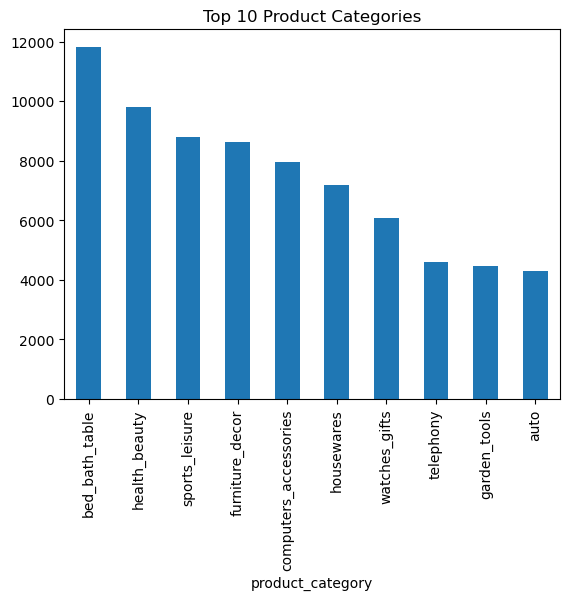

In [223]:
plt.figure()
df['product_category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Product Categories")
plt.show()

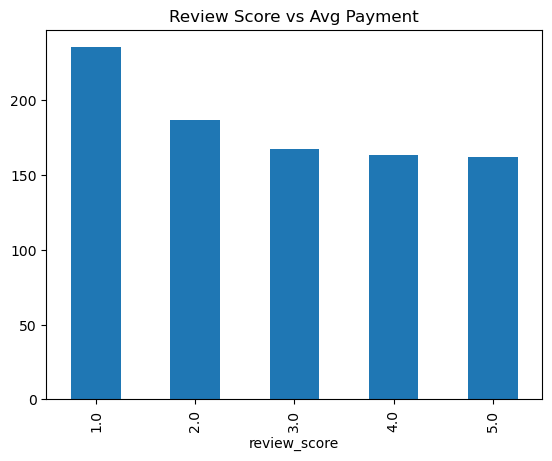

In [224]:
plt.figure()
df.groupby('review_score')['payment_value'].mean().plot(kind='bar')
plt.title("Review Score vs Avg Payment")
plt.show()

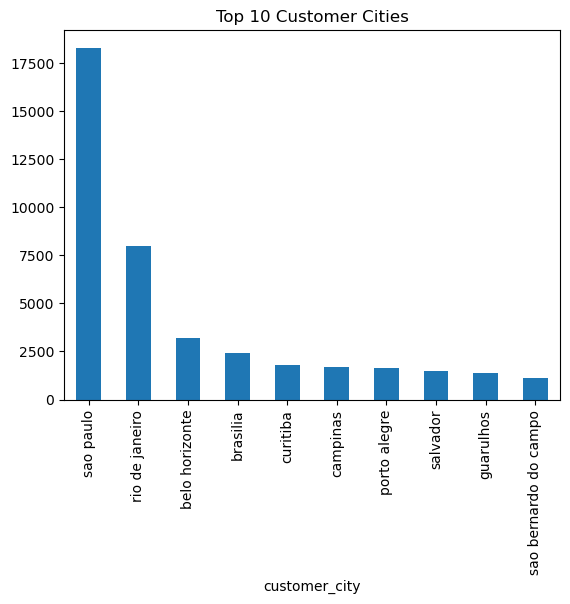

In [225]:
plt.figure()
df['customer_city'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Customer Cities")
plt.show()

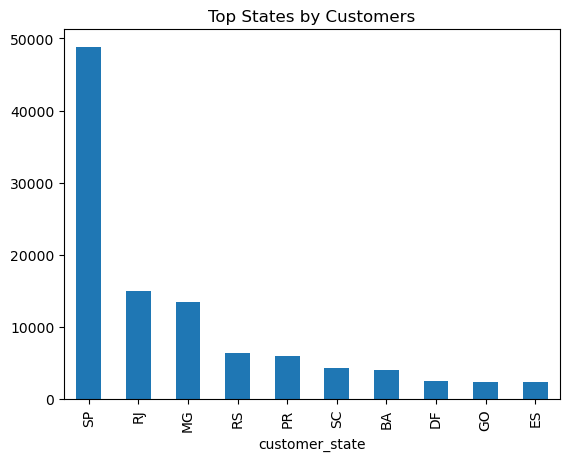

In [226]:
plt.figure()
df['customer_state'].value_counts().head(10).plot(kind='bar')
plt.title("Top States by Customers")
plt.show()

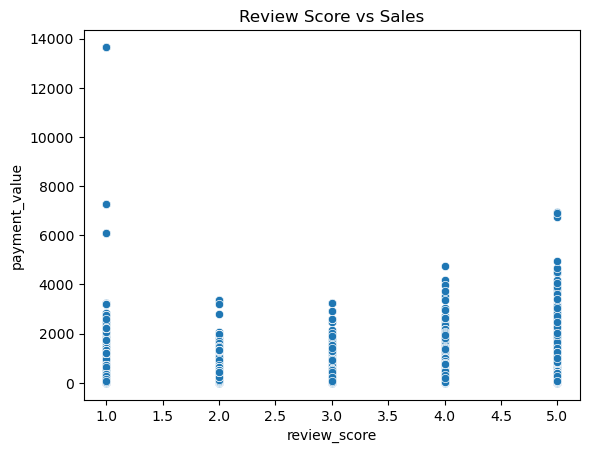

In [227]:
plt.figure()
sns.scatterplot(x=df['review_score'], y=df['payment_value'])
plt.title("Review Score vs Sales")
plt.show()

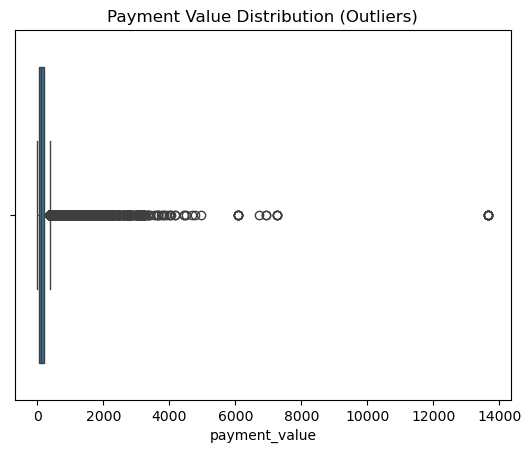

count    115715.000000
mean        171.806301
std         265.648938
min           0.000000
25%          60.830000
50%         108.100000
75%         188.940000
max       13664.080000
Name: payment_value, dtype: float64


In [228]:
plt.figure()
sns.boxplot(x=df['payment_value'])
plt.title("Payment Value Distribution (Outliers)")
plt.show()

print(df['payment_value'].describe())

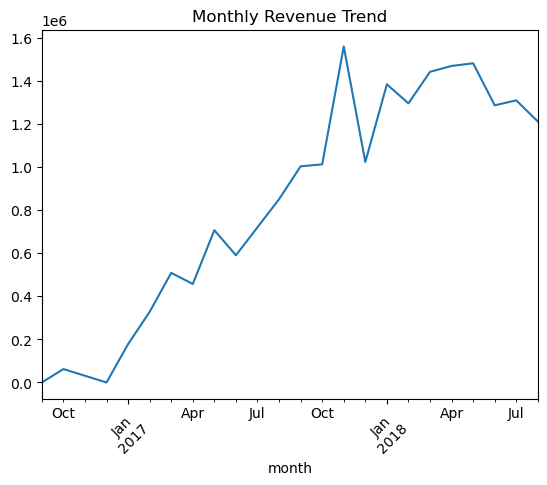

In [229]:
# Monthly Sales Trend
plt.figure()
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
df.groupby('month')['payment_value'].sum().plot()
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()
df = df.drop(columns=['month'])

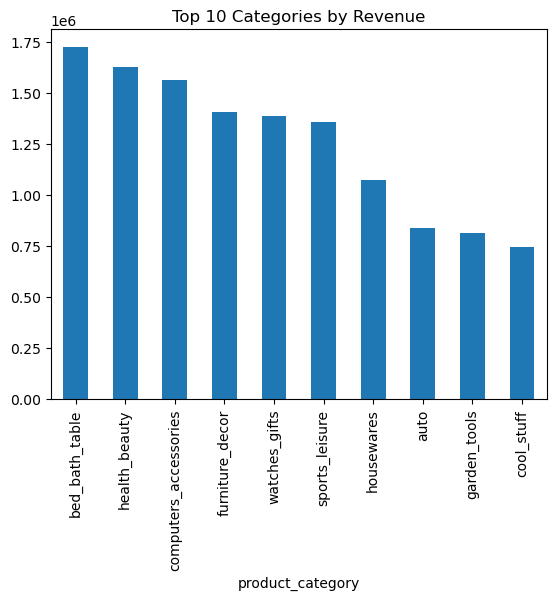

In [230]:
# Revenue per Category (مش بس count)
plt.figure()
df.groupby('product_category')['payment_value'].sum().nlargest(10).plot(kind='bar')
plt.title("Top 10 Categories by Revenue")
plt.show()

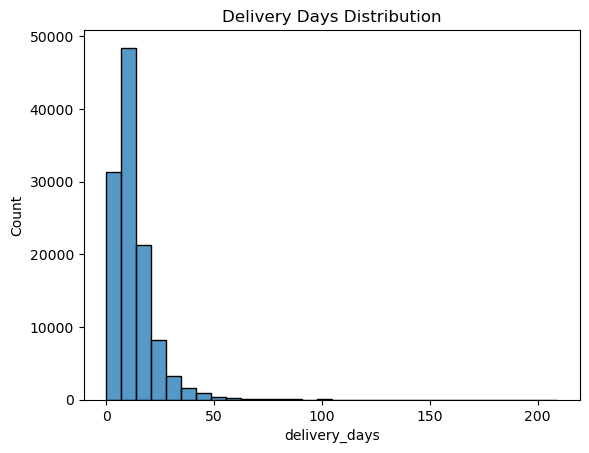

In [231]:
# Delivery Days Distribution
plt.figure()
sns.histplot(df['delivery_days'].dropna(), bins=30)
plt.title("Delivery Days Distribution")
plt.show()

In [232]:
df.to_csv("cleaned_master_df.csv", index=False)
df.to_parquet("cleaned_master_df.parquet", index=False)
print("Cleaned dataset saved (CSV + Parquet)")

Cleaned dataset saved (CSV + Parquet)


In [233]:
order_df = df.groupby('order_id').agg({
    'payment_value': 'sum',
    'order_item_id': 'count',
    'review_score': 'mean'
}).reset_index()

order_df.to_csv("order_df.csv", index=False)
order_df.to_parquet("order_df.parquet", index=False)  

print("Order-based dataset saved")

Order-based dataset saved


In [234]:
import great_expectations as gx

context = gx.get_context()

datasource = context.data_sources.add_or_update_pandas(name="my_pandas_datasource")
asset = datasource.add_dataframe_asset(name="my_df_asset")



validator = context.get_validator(batch=batch)

In [235]:
# --- Expectations ---
suite = context.suites.add_or_update(gx.ExpectationSuite(name="my_suite"))

suite.add_expectation(gx.expectations.ExpectColumnValuesToNotBeNull(column="order_id"))
suite.add_expectation(gx.expectations.ExpectColumnValuesToNotBeNull(column="product_id"))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="payment_value", min_value=0))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="review_score", min_value=1, max_value=5))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeInSet(column="order_status",value_set=["delivered", "shipped", "processing", "approved"]))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="delivery_days", min_value=0, max_value=365))
print("Expectations added")

Expectations added


In [236]:
# --- Validation ---
validation_definition = context.validation_definitions.add_or_update(
    gx.ValidationDefinition(name="my_validation", data=batch_definition, suite=suite)
)

results = validation_definition.run(
    batch_parameters={"dataframe": df}
)

print("Success:", results.success)
print("Checked Expectations:", len(results.results))
for res in results.results:
    print(res.expectation_config.type, "->", res.success)

Calculating Metrics:   0%|          | 0/44 [00:00<?, ?it/s]

Success: True
Checked Expectations: 6
expect_column_values_to_not_be_null -> True
expect_column_values_to_not_be_null -> True
expect_column_values_to_be_between -> True
expect_column_values_to_be_between -> True
expect_column_values_to_be_in_set -> True
expect_column_values_to_be_between -> True


In [237]:

# --- Save JSON ---
with open("gx_validation_results.json", "w") as f:
    json.dump(results.to_json_dict(), f, indent=2)
print("GX report saved")

GX report saved
